In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Define file paths for different scenarios
files_historical = [f'D:/Jubjang/FWICMIP6/fwisa_ann_ACCESS-CM2_historical_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
files_SSP126 = [f'D:/Jubjang/FWICMIP6/fwisa_ann_ACCESS-CM2_ssp126_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
files_SSP245 = [f'D:/Jubjang/FWICMIP6/fwisa_ann_ACCESS-CM2_ssp245_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
files_SSP370 = [f'D:/Jubjang/FWICMIP6/fwisa_ann_ACCESS-CM2_ssp370_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
file_SSP534 = 'D:/Jubjang/FWICMIP6/fwisa_ann_ACCESS-CM2_ssp534-over_r1i1p1f1_g025.nc'
files_SSP585 = [f'D:/Jubjang/FWICMIP6/fwisa_ann_ACCESS-CM2_ssp585_r{i}i1p1f1_g025.nc' for i in range(1, 6)]

# Function to load datasets from a list of file paths
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

# Load datasets
datasets_historical = load_datasets(files_historical)
datasets_SSP126 = load_datasets(files_SSP126)
datasets_SSP245 = load_datasets(files_SSP245)
datasets_SSP370 = load_datasets(files_SSP370)
dataset_SSP534 = xr.open_mfdataset(file_SSP534, combine='by_coords', engine='netcdf4')
datasets_SSP585 = load_datasets(files_SSP585)

print("Datasets successfully loaded!")
datasets_historical[0].coords['lat']

Datasets successfully loaded!


<xarray.DataArray 'lat' (lat: 72)>
array([-88.75, -86.25, -83.75, -81.25, -78.75, -76.25, -73.75, -71.25, -68.75,
       -66.25, -63.75, -61.25, -58.75, -56.25, -53.75, -51.25, -48.75, -46.25,
       -43.75, -41.25, -38.75, -36.25, -33.75, -31.25, -28.75, -26.25, -23.75,
       -21.25, -18.75, -16.25, -13.75, -11.25,  -8.75,  -6.25,  -3.75,  -1.25,
         1.25,   3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
        23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,  43.75,
        46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,  63.75,  66.25,
        68.75,  71.25,  73.75,  76.25,  78.75,  81.25,  83.75,  86.25,  88.75])
Coordinates:
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [2]:
# Define Earth's radius in meters
R = 6378137

# Latitude and longitude arrays (in degrees)
lon = datasets_historical[0].coords['lon']
lat = datasets_historical[0].coords['lat']

# Convert to radians
lon_radians = np.radians(lon)
lat_radians = np.radians(lat)

# Calculate the differences in longitude and latitude
delta_lon = np.diff(lon_radians)[0]  # Assuming regular grid
delta_lat = np.diff(lat_radians).mean()  # Take the mean for approximate spacing

# Calculate area for each grid cell
area = np.zeros((len(lat), len(lon)))  # Initialize area array to match full grid

for i in range(len(lat)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    elif i == len(lat) - 1:  # Northernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    else:  # Interior latitudes
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2

    # Calculate area for this latitude band
    area[i, :] = (R**2 * delta_lon * (np.sin(phi2) - np.sin(phi1)))

# Convert to square kilometers
area_km2 = area / 1e6

# Print or save the area array
print("Area array (in km^2):", area_km2)
print("Shape of area array:", area_km2.shape)


Area array (in km^2): [[1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 ...
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]]
Shape of area array: (72, 144)


In [3]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat = 72  # Number of latitude points
num_lon = 144  # Number of longitude points
lat = np.linspace(-88.75, 88.75, num_lat)  # Correct number of points
lon = np.linspace(1.25, 358.75, num_lon)  # Correct number of points

# Create the DataArray
areacella = xr.DataArray(
    area_km2,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella = xr.Dataset({"area": areacella})

# Inspect the Dataset
print(areacella)


<xarray.Dataset>
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03


In [4]:
# Latitude and longitude range for Thailand (adjust as needed based on data)
thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand (from 20.5°N to 5.5°N)
thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand (from 97.5°E to 105.5°E)
    
areacella_th=areacella.sel(lat=thailand_lat_range, lon=thailand_lon_range)

In [5]:
areacella_th

<xarray.Dataset>
Dimensions:  (lat: 6, lon: 3)
Coordinates:
  * lat      (lat) float64 6.25 8.75 11.25 13.75 16.25 18.75
  * lon      (lon) float64 98.75 101.2 103.8
Data variables:
    area     (lat, lon) float64 7.698e+04 7.698e+04 ... 7.333e+04 7.333e+04

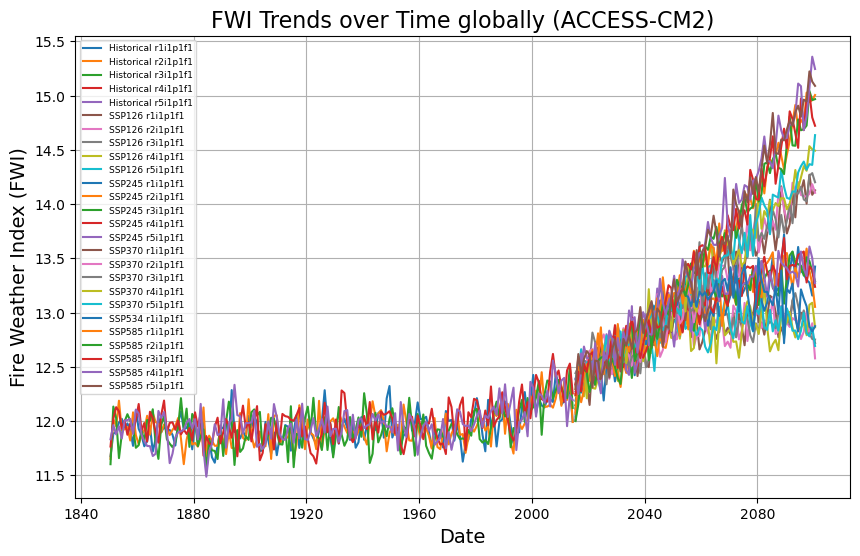

In [6]:
def plot_fwi_trends(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            dataset['fwisa'].mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=6.5)
    plt.grid(True)
    plt.savefig("FWI Trends over Time globally (ACCESS-CM2) lines only.png")
    plt.show()

# Group datasets and labels
datasets_all_scenarios = (
    datasets_historical + datasets_SSP126 + datasets_SSP245 +
    datasets_SSP370 + [dataset_SSP534] + datasets_SSP585
)

labels_all_scenarios = (
    [f'Historical r{i}i1p1f1' for i in range(1, 6)] +
    [f'SSP126 r{i}i1p1f1' for i in range(1, 6)] +
    [f'SSP245 r{i}i1p1f1' for i in range(1, 6)] +
    [f'SSP370 r{i}i1p1f1' for i in range(1, 6)] +
    ['SSP534 r1i1p1f1'] +
    [f'SSP585 r{i}i1p1f1' for i in range(1, 6)]
)

# Plot FWI trends for all scenarios
plot_fwi_trends(datasets_all_scenarios, labels_all_scenarios, 'FWI Trends over Time globally (ACCESS-CM2)')

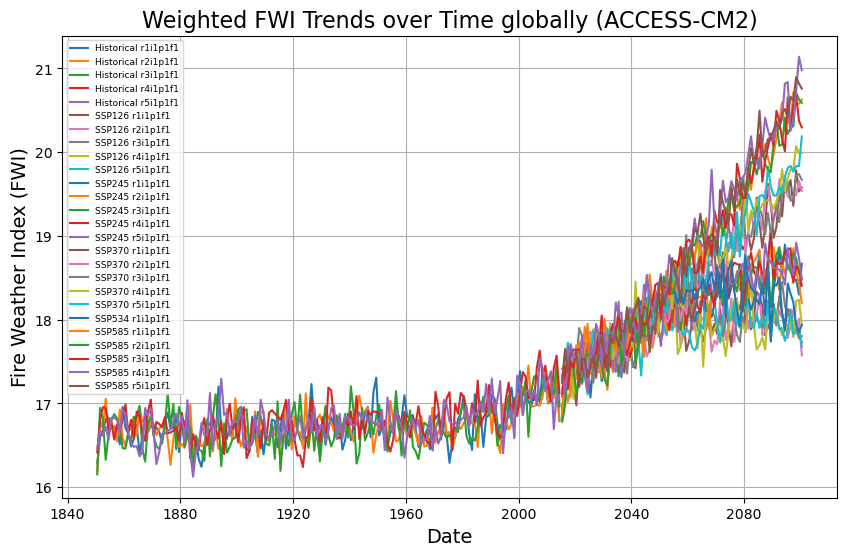

In [7]:
def plot_fwi_trends(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=6.5)
    plt.grid(True)
    plt.savefig("Weighted FWI Trends over Time globally (ACCESS-CM2) lines only.png")
    plt.show()

# Group datasets and labels
datasets_all_scenarios = (
    datasets_historical + datasets_SSP126 + datasets_SSP245 +
    datasets_SSP370 + [dataset_SSP534] + datasets_SSP585
)

labels_all_scenarios = (
    [f'Historical r{i}i1p1f1' for i in range(1, 6)] +
    [f'SSP126 r{i}i1p1f1' for i in range(1, 6)] +
    [f'SSP245 r{i}i1p1f1' for i in range(1, 6)] +
    [f'SSP370 r{i}i1p1f1' for i in range(1, 6)] +
    ['SSP534 r1i1p1f1'] +
    [f'SSP585 r{i}i1p1f1' for i in range(1, 6)]
)

# Plot FWI trends for all scenarios
plot_fwi_trends(datasets_all_scenarios, labels_all_scenarios, 'Weighted FWI Trends over Time globally (ACCESS-CM2)')

In [8]:
print(datasets_historical[0].coords['lat'].values)
print(datasets_historical[0].coords['lon'].values)

[-88.75 -86.25 -83.75 -81.25 -78.75 -76.25 -73.75 -71.25 -68.75 -66.25
 -63.75 -61.25 -58.75 -56.25 -53.75 -51.25 -48.75 -46.25 -43.75 -41.25
 -38.75 -36.25 -33.75 -31.25 -28.75 -26.25 -23.75 -21.25 -18.75 -16.25
 -13.75 -11.25  -8.75  -6.25  -3.75  -1.25   1.25   3.75   6.25   8.75
  11.25  13.75  16.25  18.75  21.25  23.75  26.25  28.75  31.25  33.75
  36.25  38.75  41.25  43.75  46.25  48.75  51.25  53.75  56.25  58.75
  61.25  63.75  66.25  68.75  71.25  73.75  76.25  78.75  81.25  83.75
  86.25  88.75]
[  1.25   3.75   6.25   8.75  11.25  13.75  16.25  18.75  21.25  23.75
  26.25  28.75  31.25  33.75  36.25  38.75  41.25  43.75  46.25  48.75
  51.25  53.75  56.25  58.75  61.25  63.75  66.25  68.75  71.25  73.75
  76.25  78.75  81.25  83.75  86.25  88.75  91.25  93.75  96.25  98.75
 101.25 103.75 106.25 108.75 111.25 113.75 116.25 118.75 121.25 123.75
 126.25 128.75 131.25 133.75 136.25 138.75 141.25 143.75 146.25 148.75
 151.25 153.75 156.25 158.75 161.25 163.75 166.25 168.75 171.

<xarray.DataArray 'fwisa' (time: 165, lat: 6, lon: 3)>
dask.array<getitem, shape=(165, 6, 3), dtype=float64, chunksize=(165, 6, 3), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 98.75 101.2 103.8
  * lat      (lat) float64 6.25 8.75 11.25 13.75 16.25 18.75
  * time     (time) datetime64[ns] 1850-07-01T06:00:00 ... 2014-07-01T06:00:00
Attributes:
    method_fwisa:   Annual peak of a 90 days average
    units:          1
    long_name:      Seasonal Average Of The Fire Weather Index
    standard_name:  fire_weather_index
<xarray.DataArray 'fwisa' (time: 165, lat: 6, lon: 3)>
dask.array<getitem, shape=(165, 6, 3), dtype=float64, chunksize=(165, 6, 3), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 98.75 101.2 103.8
  * lat      (lat) float64 6.25 8.75 11.25 13.75 16.25 18.75
  * time     (time) datetime64[ns] 1850-07-01T06:00:00 ... 2014-07-01T06:00:00
Attributes:
    method_fwisa:   Annual peak of a 90 days average
    units:          1
    long_name:

<xarray.DataArray 'fwisa' (time: 86, lat: 6, lon: 3)>
dask.array<getitem, shape=(86, 6, 3), dtype=float64, chunksize=(86, 6, 3), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 98.75 101.2 103.8
  * lat      (lat) float64 6.25 8.75 11.25 13.75 16.25 18.75
  * time     (time) datetime64[ns] 2015-07-01T06:00:00 ... 2100-07-01T06:00:00
Attributes:
    method_fwisa:   Annual peak of a 90 days average
    units:          1
    long_name:      Seasonal Average Of The Fire Weather Index
    standard_name:  fire_weather_index


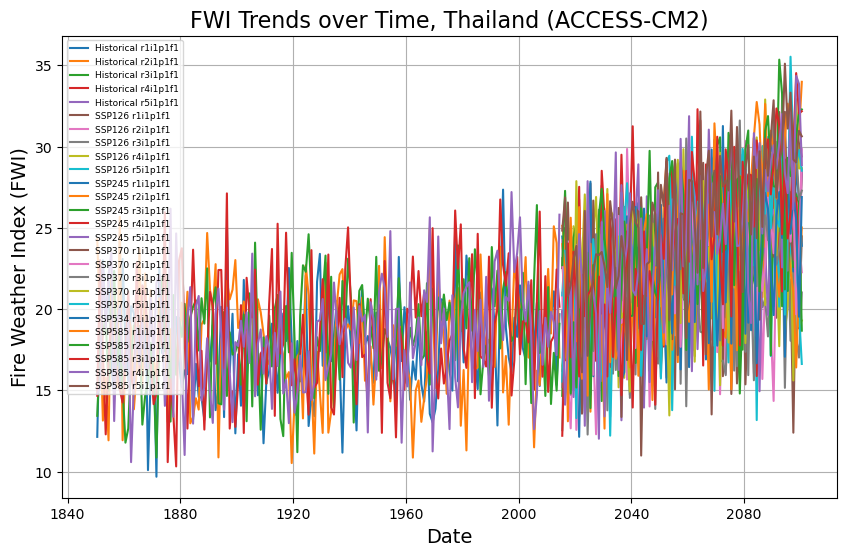

In [9]:
def plot_fwi_trends_th(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets with a focus on Thailand's geographic area. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 6))
    
    # Latitude and longitude range for Thailand (adjust as needed based on data)
    thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand (from 20.5°N to 5.5°N)
    thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand (from 97.5°E to 105.5°E)
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        try:
            # Slice the dataset based on Thailand's lat-lon range
            sliced_data = dataset['fwisa'].sel(lat=thailand_lat_range, lon=thailand_lon_range)
            print(sliced_data)
            # Check if the sliced data has values
            if sliced_data.size == 0:
                print(f"Warning: No data for {label} in the selected lat-lon range.")
            else:
                # Plot the mean over the selected region
                plt.plot(
                    dataset['time'], 
                    sliced_data.mean(dim=['lat', 'lon']), 
                    label=label
                )
        
        except KeyError as e:
            print(f"Error slicing data for {label}: {e}")
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=6.5)
    plt.grid(True)
    plt.savefig("FWI Trends over Time, Thailand (ACCESS-CM2).png")
    plt.show()

# Group datasets and labels
datasets_all_scenarios = (
    datasets_historical + datasets_SSP126 + datasets_SSP245 +
    datasets_SSP370 + [dataset_SSP534] + datasets_SSP585
)

labels_all_scenarios = (
    [f'Historical r{i}i1p1f1' for i in range(1, 6)] +
    [f'SSP126 r{i}i1p1f1' for i in range(1, 6)] +
    [f'SSP245 r{i}i1p1f1' for i in range(1, 6)] +
    [f'SSP370 r{i}i1p1f1' for i in range(1, 6)] +
    ['SSP534 r1i1p1f1'] +
    [f'SSP585 r{i}i1p1f1' for i in range(1, 6)]
)

# Plot FWI trends for all scenarios
plot_fwi_trends_th(datasets_all_scenarios, labels_all_scenarios, 'FWI Trends over Time, Thailand (ACCESS-CM2)')


In [10]:
# areacella_ACCESS_CM2_historical= xr.open_dataset('D:/Jubjang/FWICMIP6/areacella_fx_ACCESS-CM2_historical_r1i1p1f1_gn.nc')
# aw_xrth = areacella_ACCESS_CM2_historical['areacella'].sel(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))

In [11]:
# aw_xrth.load() #ไม่ตรงกับที่ระบุ ต้องทำ areacella เอง

In [12]:
def load_and_concatenate(file_list):
    datasets = [xr.open_dataset(file, engine='netcdf4') for file in file_list]
    concatenated = xr.concat(datasets, dim='ensemble')
    return concatenated

In [13]:
# Load and compute ensemble mean and standard deviation for historical data
historical_data = load_and_concatenate(files_historical)
ensemble_mean_historical = (historical_data.weighted(areacella['area']).mean(dim=['lat','lon'])).mean(dim='ensemble')
ensemble_std_historical = (historical_data.weighted(areacella['area']).mean(dim=['lat','lon'])).std(dim='ensemble')

# Load and compute ensemble mean and standard deviation for each SSP scenario
ssp126_data = load_and_concatenate(files_SSP126)
ensemble_mean_ssp126 = (ssp126_data.weighted(areacella['area']).mean(dim=['lat','lon'])).mean(dim='ensemble')
ensemble_std_ssp126 = (ssp126_data.weighted(areacella['area']).mean(dim=['lat','lon'])).std(dim='ensemble')

ssp245_data = load_and_concatenate(files_SSP245)
ensemble_mean_ssp245 = (ssp245_data.weighted(areacella['area']).mean(dim=['lat','lon'])).mean(dim='ensemble')
ensemble_std_ssp245 = (ssp245_data.weighted(areacella['area']).mean(dim=['lat','lon'])).std(dim='ensemble')

ssp370_data = load_and_concatenate(files_SSP370)
ensemble_mean_ssp370 = (ssp370_data.weighted(areacella['area']).mean(dim=['lat','lon'])).mean(dim='ensemble')
ensemble_std_ssp370 = (ssp370_data.weighted(areacella['area']).mean(dim=['lat','lon'])).std(dim='ensemble')

# For SSP534, no ensemble dimension exists, so no concatenation is needed.
ssp534_data = xr.open_dataset(file_SSP534, engine='netcdf4')  # Only one file for SSP534
ensemble_mean_ssp534 = ssp534_data.weighted(areacella['area']).mean(dim=['lat','lon'])
ensemble_std_ssp534 = ssp534_data.weighted(areacella['area']).mean(dim=['lat','lon'])

ssp585_data = load_and_concatenate(files_SSP585)
ensemble_mean_ssp585 = (ssp585_data.weighted(areacella['area']).mean(dim=['lat','lon'])).mean(dim='ensemble')
ensemble_std_ssp585 = (ssp585_data.weighted(areacella['area']).mean(dim=['lat','lon'])).std(dim='ensemble')

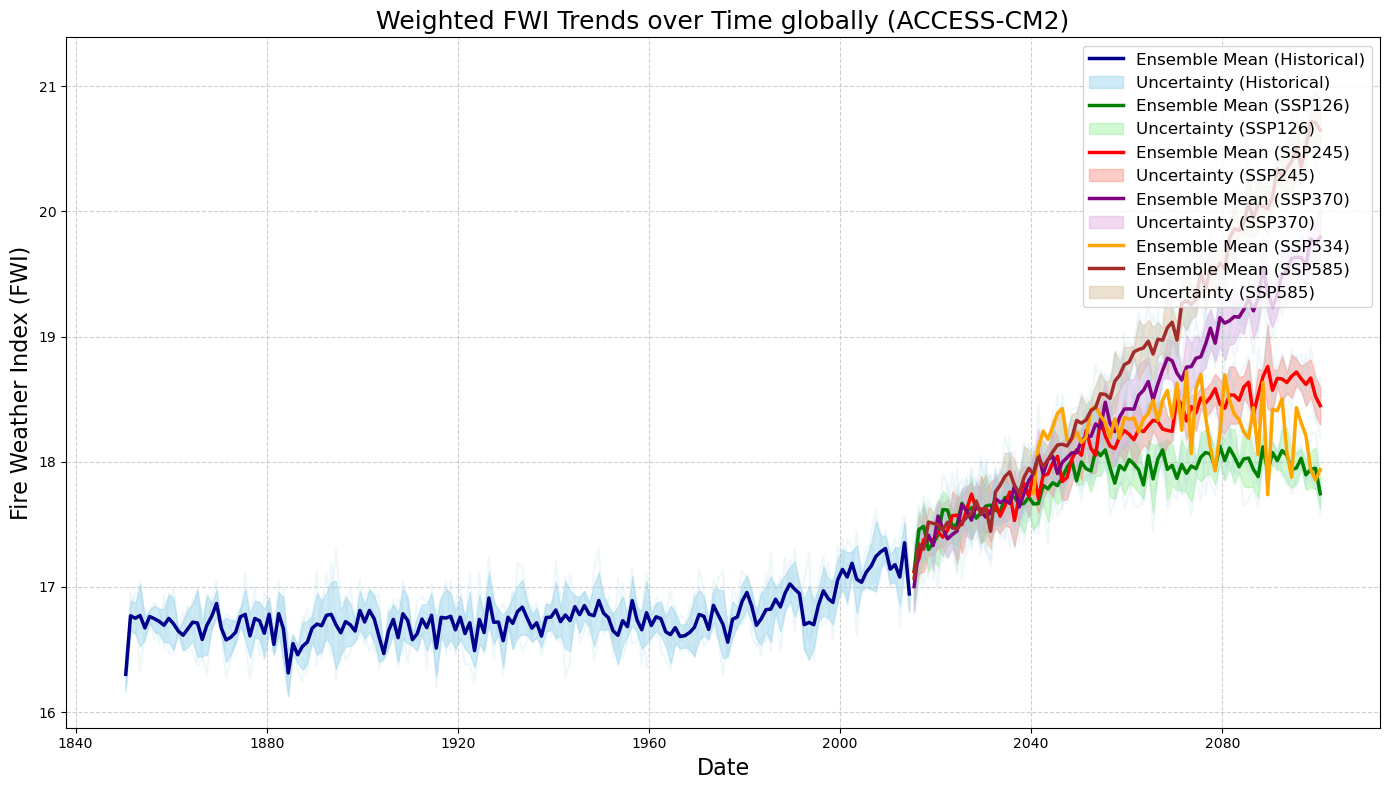

In [14]:
def plot_fwi_trends(datasets, ensemble_means, ensemble_stds, title):
    """ 
    Plot FWI trends over time for given datasets with ensemble mean and boundaries.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        ensemble_stds (list): List of xarray DataArrays for ensemble standard deviations.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(14, 8))  # Increase plot size

    # Plot individual datasets in a lighter color
    for dataset in datasets[:200]:  # Limit to first 10 datasets for clarity
        # Ensure the 'time' coordinate exists in the dataset
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            # Spatially average to reduce to 1D (time dimension only)
            spatial_mean = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
            #spatial_mean = dataset['fwisa'].mean(dim=['lat', 'lon'], skipna=True)
            plt.plot(
                time, 
                spatial_mean, 
                color='lightblue', alpha=0.2  # Increase transparency
            )

    # Define distinct colors for each ensemble mean
    colors = ['darkblue', 'green', 'red', 'purple', 'orange', 'brown']
    boundary_colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold', 'tan']  # Custom boundary colors
    scenario_labels = ['Historical', 'SSP126', 'SSP245', 'SSP370', 'SSP534', 'SSP585']
    
    # Plot each ensemble mean in a distinct color with a dynamic label
    for ensemble_mean, ensemble_std, label, color, boundary_color in zip(ensemble_means, ensemble_stds, scenario_labels, colors, boundary_colors):
        # Extract DataArrays (assuming fwisa is the variable of interest)
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']
        if isinstance(ensemble_std, xr.Dataset):
            ensemble_std = ensemble_std['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            # Ensemble mean should already be spatially averaged
            plt.plot(
                time, 
                ensemble_mean, 
                color=color, linewidth=2.5, label=f'Ensemble Mean ({label})'
            )
            
            # Skip uncertainty for SSP534
            if label == 'SSP534':
                continue
            
            # Calculate the uncertainty bounds (lower and upper)
            lower_bound = ensemble_mean - ensemble_std
            upper_bound = ensemble_mean + ensemble_std
            
            # Plot the shaded region representing uncertainty
            plt.fill_between(
                time, 
                lower_bound, 
                upper_bound, 
                color=boundary_color, alpha=0.40, label=f'Uncertainty ({label})'
            )
    
    # Plot customization
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper right')  # Increase legend font size
    plt.grid(True, linestyle='--', alpha=0.6)  # Add grid with more transparency
    plt.tight_layout()
    plt.savefig("Weighted FWI Trends over Time globally (ACCESS-CM2).png")
    plt.show()

# Example input (replace with your actual data)
ensemble_means_all_scenarios = [
    ensemble_mean_historical, 
    ensemble_mean_ssp126, 
    ensemble_mean_ssp245, 
    ensemble_mean_ssp370, 
    ensemble_mean_ssp534, 
    ensemble_mean_ssp585
]
ensemble_stds_all_scenarios = [
    ensemble_std_historical, 
    ensemble_std_ssp126, 
    ensemble_std_ssp245, 
    ensemble_std_ssp370, 
    ensemble_std_ssp534, 
    ensemble_std_ssp585
]

# Plot the FWI trends over time for all scenarios with ensemble means and boundaries
plot_fwi_trends(
    datasets_all_scenarios, 
    ensemble_means_all_scenarios, 
    ensemble_stds_all_scenarios, 
    'Weighted FWI Trends over Time globally (ACCESS-CM2)'
)


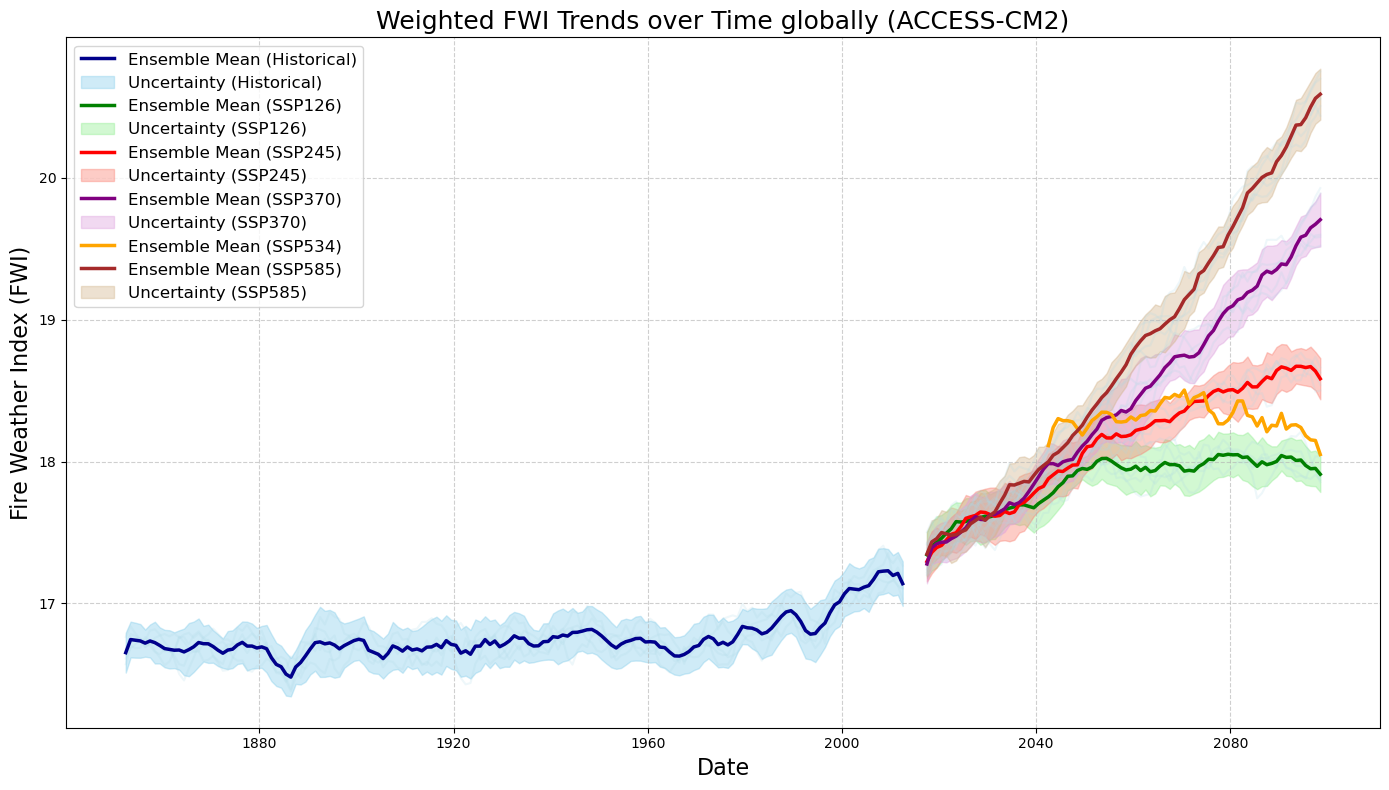

In [15]:
def plot_fwi_trends(datasets, ensemble_means, ensemble_stds, title, window_size=12):
    """ 
    Plot FWI trends over time for given datasets with ensemble mean and boundaries.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        ensemble_stds (list): List of xarray DataArrays for ensemble standard deviations.
        title (str): Title for the plot.
        window_size (int): Window size for moving average (default: 12 for annual smoothing).
    """
    plt.figure(figsize=(14, 8))  # Increase plot size

    # Plot individual datasets in a lighter color
    for dataset in datasets[:200]:  # Limit to first 200 datasets for clarity
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            # Spatially average and apply a moving average
            spatial_mean = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
            spatial_mean_smooth = spatial_mean.rolling(time=window_size, center=True).mean()

            plt.plot(
                time, 
                spatial_mean_smooth, 
                color='lightblue', alpha=0.2  # Increase transparency
            )

    # Define distinct colors for each ensemble mean
    colors = ['darkblue', 'green', 'red', 'purple', 'orange', 'brown']
    boundary_colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold', 'tan']
    scenario_labels = ['Historical', 'SSP126', 'SSP245', 'SSP370', 'SSP534', 'SSP585']
    
    # Plot each ensemble mean with moving average
    for ensemble_mean, ensemble_std, label, color, boundary_color in zip(ensemble_means, ensemble_stds, scenario_labels, colors, boundary_colors):
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']
        if isinstance(ensemble_std, xr.Dataset):
            ensemble_std = ensemble_std['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            # Apply a moving average to the ensemble mean
            ensemble_mean_smooth = ensemble_mean.rolling(time=window_size, center=True).mean()
            
            plt.plot(
                time, 
                ensemble_mean_smooth, 
                color=color, linewidth=2.5, label=f'Ensemble Mean ({label})'
            )
            
            # Skip uncertainty for SSP534
            if label == 'SSP534':
                continue
            
            # Apply moving average to uncertainty bounds
            lower_bound = (ensemble_mean - ensemble_std).rolling(time=window_size, center=True).mean()
            upper_bound = (ensemble_mean + ensemble_std).rolling(time=window_size, center=True).mean()
            
            # Plot the shaded region for uncertainty
            plt.fill_between(
                time, 
                lower_bound, 
                upper_bound, 
                color=boundary_color, alpha=0.40, label=f'Uncertainty ({label})'
            )
    
    # Plot customization
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper left')  
    plt.grid(True, linestyle='--', alpha=0.6)  
    plt.tight_layout()
    plt.savefig(f"Weighted FWI Trends ({title}).png")
    plt.show()

# Example input (replace with actual data)
plot_fwi_trends(
    datasets_all_scenarios, 
    ensemble_means_all_scenarios, 
    ensemble_stds_all_scenarios, 
    'Weighted FWI Trends over Time globally (ACCESS-CM2)', 
    window_size=5  # Apply a 12-month moving average
)

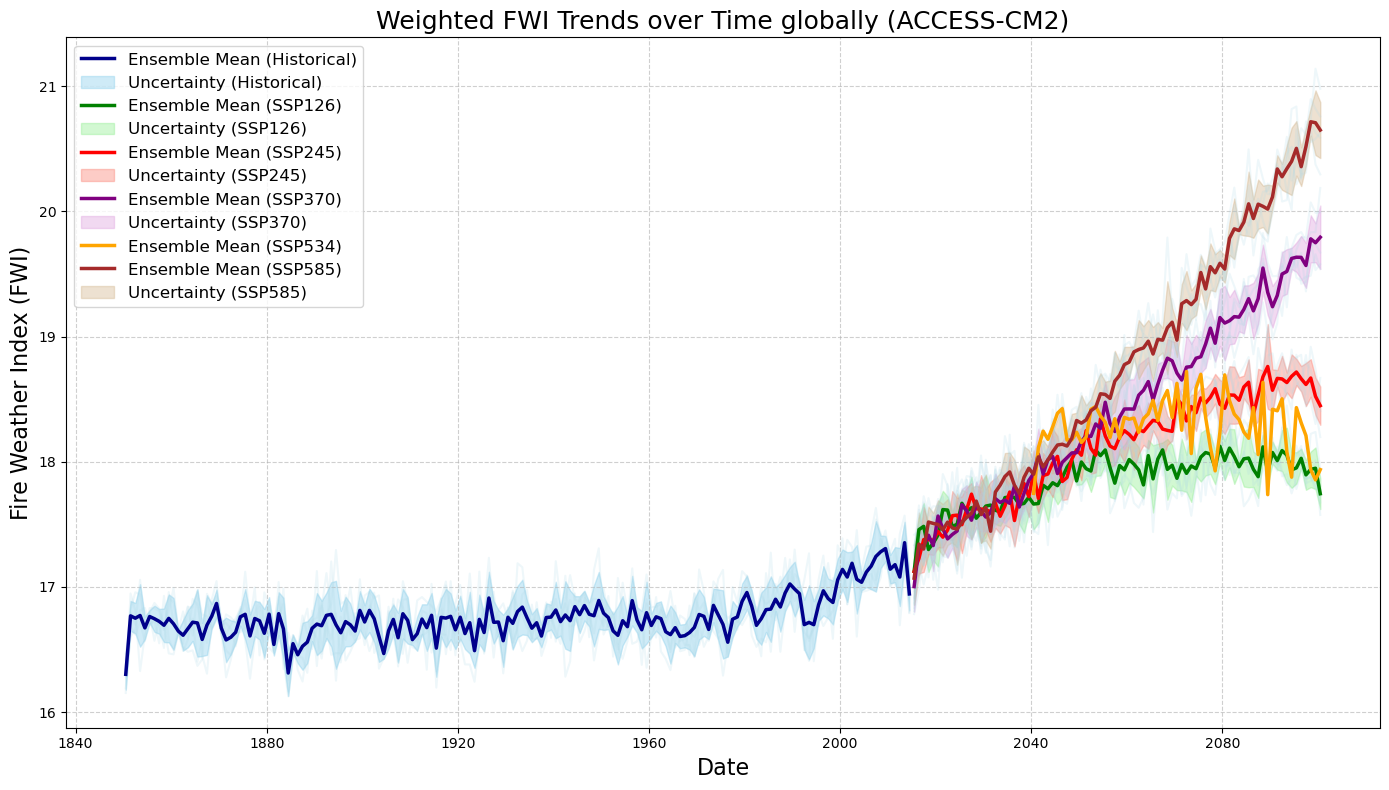

In [16]:
def plot_fwi_trends_weighted(datasets, ensemble_means, ensemble_stds, title, areacella_th):
    """ 
    Plot FWI trends over time for given datasets with ensemble mean and boundaries.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        ensemble_stds (list): List of xarray DataArrays for ensemble standard deviations.
        title (str): Title for the plot.
        areacella_th (xarray.DataArray): Area weights for lat-lon grid.
    """
    plt.figure(figsize=(14, 8))  # Increase plot size

    # Plot individual datasets in a lighter color
    for dataset in datasets[:200]:  # Limit to first 200 datasets for clarity
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            # Apply weighted mean using areacella_th
            spatial_mean = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
            plt.plot(
                time, 
                spatial_mean, 
                color='lightblue', alpha=0.2  # Increase transparency
            )

    # Define distinct colors for each ensemble mean
    colors = ['darkblue', 'green', 'red', 'purple', 'orange', 'brown']
    boundary_colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold', 'tan']  # Custom boundary colors
    scenario_labels = ['Historical', 'SSP126', 'SSP245', 'SSP370', 'SSP534', 'SSP585']
    
    # Plot each ensemble mean in a distinct color with a dynamic label
    for ensemble_mean, ensemble_std, label, color, boundary_color in zip(ensemble_means, ensemble_stds, scenario_labels, colors, boundary_colors):
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']
        if isinstance(ensemble_std, xr.Dataset):
            ensemble_std = ensemble_std['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            plt.plot(
                time, 
                ensemble_mean, 
                color=color, linewidth=2.5, label=f'Ensemble Mean ({label})'
            )
            
            if label == 'SSP534':
                continue
            
            lower_bound = ensemble_mean - ensemble_std
            upper_bound = ensemble_mean + ensemble_std
            
            plt.fill_between(
                time, 
                lower_bound, 
                upper_bound, 
                color=boundary_color, alpha=0.40, label=f'Uncertainty ({label})'
            )
    
    # Plot customization
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig("Weighted FWI Trends over Time globally (ACCESS-CM2).png")
    plt.show()
    
plot_fwi_trends_weighted(
    datasets_all_scenarios,  # List of individual datasets
    ensemble_means_all_scenarios,  # List of ensemble mean DataArrays
    ensemble_stds_all_scenarios,  # List of ensemble std DataArrays
    'Weighted FWI Trends over Time globally (ACCESS-CM2)',  # Title
    areacella['area']  # Area weights
)


In [17]:
print(areacella.dims)  # Should be ('lat', 'lon')
print(areacella['area'].shape)  # Should match the spatial dimensions of fwisa

Frozen({'lat': 72, 'lon': 144})
(72, 144)


In [18]:
print(datasets_all_scenarios[0].dims)  # Should be ('lat', 'lon')
print(datasets_all_scenarios[0]['fwisa'].shape)  # Should match the spatial dimensions of fwisa

Frozen({'lon': 144, 'lat': 72, 'time': 165})
(165, 72, 144)


In [19]:
# Check dimensions of `fwisa` in one dataset
print("FWISA dimensions:", datasets_all_scenarios[0]['fwisa'].dims)

# Check dimensions of `areacella`
print("Areacella dimensions:", areacella.dims)

# Check the shapes of `fwisa` and `areacella`
print("FWISA shape:", datasets_all_scenarios[0]['fwisa'].shape)
print("Areacella shape:", areacella['area'].shape)

# Check coordinates of `fwisa`
print("FWISA coordinates:", datasets_all_scenarios[0]['fwisa'].coords)

# Check coordinates of `areacella`
print("Areacella coordinates:", areacella.coords)

FWISA dimensions: ('time', 'lat', 'lon')
Areacella dimensions: Frozen({'lat': 72, 'lon': 144})
FWISA shape: (165, 72, 144)
Areacella shape: (72, 144)
FWISA coordinates: Coordinates:
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * time     (time) datetime64[ns] 1850-07-01T06:00:00 ... 2014-07-01T06:00:00
Areacella coordinates: Coordinates:
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8


In [20]:
# Define latitude and longitude range for Thailand
thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand
thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand

# Load and compute ensemble mean and standard deviation for historical data
historical_data_th = load_and_concatenate(files_historical).sel(lat=thailand_lat_range, lon=thailand_lon_range)
areacella_th = areacella.sel(lat=thailand_lat_range, lon=thailand_lon_range)
ensemble_mean_historical_th = (historical_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
ensemble_std_historical_th = (historical_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')

# Load and compute ensemble mean and standard deviation for SSP scenarios
ssp126_data_th = load_and_concatenate(files_SSP126).sel(lat=thailand_lat_range, lon=thailand_lon_range)
ensemble_mean_ssp126_th = (ssp126_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
ensemble_std_ssp126_th = (ssp126_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')

ssp245_data_th = load_and_concatenate(files_SSP245).sel(lat=thailand_lat_range, lon=thailand_lon_range)
ensemble_mean_ssp245_th = (ssp245_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
ensemble_std_ssp245_th = (ssp245_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')

ssp370_data_th = load_and_concatenate(files_SSP370).sel(lat=thailand_lat_range, lon=thailand_lon_range)
ensemble_mean_ssp370_th = (ssp370_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
ensemble_std_ssp370_th = (ssp370_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')

# SSP534 does not have ensemble dimensions
ssp534_data_th = xr.open_dataset(file_SSP534, engine='netcdf4').sel(lat=thailand_lat_range, lon=thailand_lon_range)
ensemble_mean_ssp534_th = ssp534_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])
ensemble_std_ssp534_th = ssp534_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])

ssp585_data_th = load_and_concatenate(files_SSP585).sel(lat=thailand_lat_range, lon=thailand_lon_range)
ensemble_mean_ssp585_th = (ssp585_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
ensemble_std_ssp585_th = (ssp585_data_th.weighted(areacella_th['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')

In [21]:
# Example input (replace with your actual data)
ensemble_means_all_scenarios_th = [
    ensemble_mean_historical_th, 
    ensemble_mean_ssp126_th, 
    ensemble_mean_ssp245_th, 
    ensemble_mean_ssp370_th, 
    ensemble_mean_ssp534_th, 
    ensemble_mean_ssp585_th
]
ensemble_stds_all_scenarios_th = [
    ensemble_std_historical_th, 
    ensemble_std_ssp126_th, 
    ensemble_std_ssp245_th, 
    ensemble_std_ssp370_th, 
    ensemble_std_ssp534_th, 
    ensemble_std_ssp585_th
]

In [22]:
def plot_fwi_trends_weighted_th(datasets, ensemble_means, ensemble_stds, title, areacella_th):
    """ 
    Plot FWI trends over time for given datasets with ensemble mean and boundaries.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        ensemble_stds (list): List of xarray DataArrays for ensemble standard deviations.
        title (str): Title for the plot.
        areacella_th (xarray.DataArray): Area weights for lat-lon grid.
    """
    plt.figure(figsize=(14, 8))  # Increase plot size

    # Plot individual datasets in a lighter color
    for dataset in datasets[:200]:  # Limit to first 200 datasets for clarity
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            # Apply weighted mean using areacella_th
            dataset = dataset.sel(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))
            spatial_mean = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
            plt.plot(
                time, 
                spatial_mean, 
                color='lightyellow', alpha=0.8  # Increase transparency
            )

    # Define distinct colors for each ensemble mean
    colors = ['darkblue', 'green', 'red', 'purple', 'orange', 'brown']
    boundary_colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold', 'tan']  # Custom boundary colors
    scenario_labels = ['Historical', 'SSP126', 'SSP245', 'SSP370', 'SSP534', 'SSP585']
    
    # Plot each ensemble mean in a distinct color with a dynamic label
    for ensemble_mean, ensemble_std, label, color, boundary_color in zip(ensemble_means, ensemble_stds, scenario_labels, colors, boundary_colors):
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']
        if isinstance(ensemble_std, xr.Dataset):
            ensemble_std = ensemble_std['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            plt.plot(
                time, 
                ensemble_mean, 
                color=color, linewidth=2.5, label=f'Ensemble Mean ({label})'
            )
            
            if label == 'SSP534':
                continue
            
            lower_bound = ensemble_mean - ensemble_std
            upper_bound = ensemble_mean + ensemble_std
            
            plt.fill_between(
                time, 
                lower_bound, 
                upper_bound, 
                color=boundary_color, alpha=0.40, label=f'Uncertainty ({label})'
            )
    
    # Plot customization
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig("Weighted FWI Trends over Time, Thailand (ACCESS-CM2).png")
    plt.show()

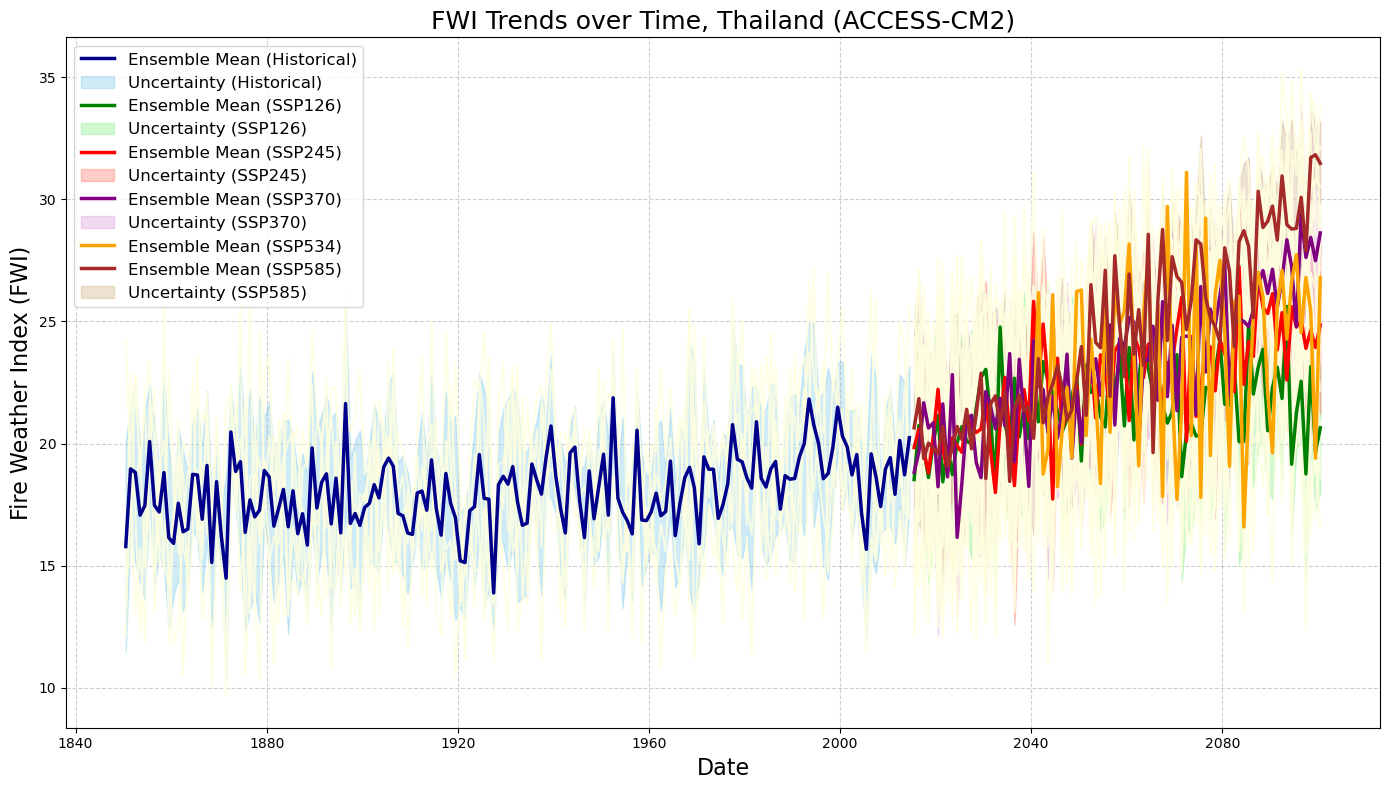

In [23]:
plot_fwi_trends_weighted_th(
    datasets_all_scenarios,  # List of individual datasets
    ensemble_means_all_scenarios_th,  # List of ensemble mean DataArrays
    ensemble_stds_all_scenarios_th,  # List of ensemble std DataArrays
    'FWI Trends over Time, Thailand (ACCESS-CM2)',  # Title
    areacella_th['area']  # Area weights
)

In [24]:
def plot_fwi_trends_weighted_th_withouteachline(datasets, ensemble_means, ensemble_stds, title, areacella_th):
    """ 
    Plot FWI trends over time for given datasets with ensemble mean and boundaries.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        ensemble_stds (list): List of xarray DataArrays for ensemble standard deviations.
        title (str): Title for the plot.
        areacella_th (xarray.DataArray): Area weights for lat-lon grid.
    """
    plt.figure(figsize=(14, 8))  # Increase plot size

    # Plot individual datasets in a lighter color
    for dataset in datasets[:200]:  # Limit to first 200 datasets for clarity
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            # Apply weighted mean using areacella_th
            dataset = dataset.sel(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))
            spatial_mean = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
            plt.plot(
                time, 
                spatial_mean, 
                color='lightyellow', alpha=0  # Increase transparency
            )

    # Define distinct colors for each ensemble mean
    colors = ['darkblue', 'green', 'red', 'purple', 'orange', 'brown']
    boundary_colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold', 'tan']  # Custom boundary colors
    scenario_labels = ['Historical', 'SSP126', 'SSP245', 'SSP370', 'SSP534', 'SSP585']
    
    # Plot each ensemble mean in a distinct color with a dynamic label
    for ensemble_mean, ensemble_std, label, color, boundary_color in zip(ensemble_means, ensemble_stds, scenario_labels, colors, boundary_colors):
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']
        if isinstance(ensemble_std, xr.Dataset):
            ensemble_std = ensemble_std['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            plt.plot(
                time, 
                ensemble_mean, 
                color=color, linewidth=2.5, label=f'Ensemble Mean ({label})'
            )
            
            if label == 'SSP534':
                continue
            
            lower_bound = ensemble_mean - ensemble_std
            upper_bound = ensemble_mean + ensemble_std
            
            plt.fill_between(
                time, 
                lower_bound, 
                upper_bound, 
                color=boundary_color, alpha=0.40, label=f'Uncertainty ({label})'
            )
    
    # Plot customization
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig("Weighted FWI Trends over Time, Thailand (ACCESS-CM2) without lines.png")
    plt.show()

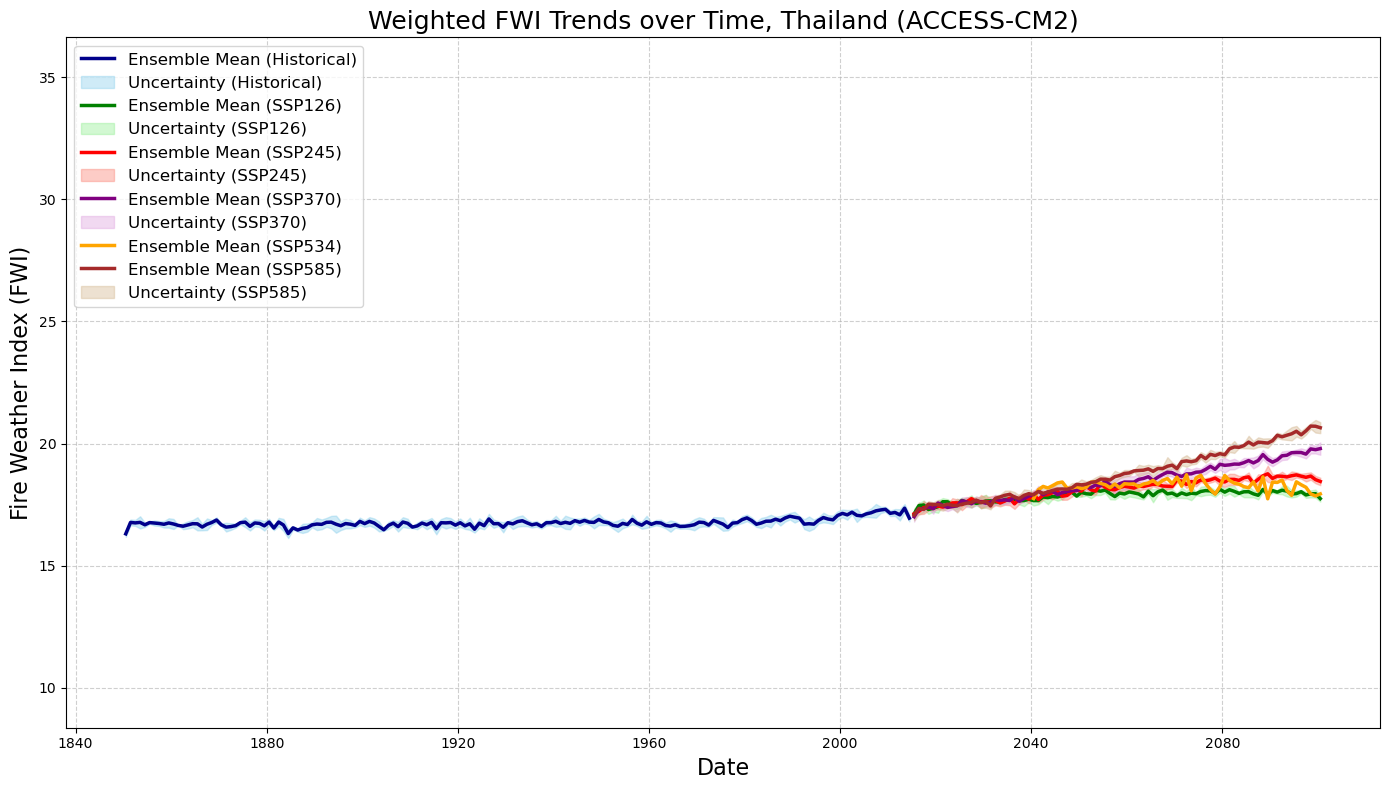

In [25]:
def plot_fwi_trends_weighted_th_withouteachline(datasets, ensemble_means, ensemble_stds, title, areacella_th, window_size=12):
    """ 
    Plot FWI trends over time for given datasets with ensemble mean and boundaries.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        ensemble_stds (list): List of xarray DataArrays for ensemble standard deviations.
        title (str): Title for the plot.
        areacella_th (xarray.DataArray): Area weights for lat-lon grid.
        window_size (int): Window size for moving average (default: 12 for annual smoothing).
    """
    plt.figure(figsize=(14, 8))  # Increase plot size

    # Plot individual datasets but hide the lines
    for dataset in datasets[:200]:  # Limit to first 200 datasets for clarity
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            dataset = dataset.sel(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))
            spatial_mean = dataset['fwisa'].weighted(areacella_th['area']).mean(dim=['lat', 'lon'], skipna=True)
            spatial_mean_smooth = spatial_mean.rolling(time=window_size, center=True).mean()
            
            plt.plot(
                time, 
                spatial_mean_smooth, 
                color='lightyellow', alpha=0  # Hide individual lines
            )

    # Define distinct colors for each ensemble mean
    colors = ['darkblue', 'green', 'red', 'purple', 'orange', 'brown']
    boundary_colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold', 'tan']
    scenario_labels = ['Historical', 'SSP126', 'SSP245', 'SSP370', 'SSP534', 'SSP585']
    
    # Plot each ensemble mean with moving average
    for ensemble_mean, ensemble_std, label, color, boundary_color in zip(ensemble_means, ensemble_stds, scenario_labels, colors, boundary_colors):
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']
        if isinstance(ensemble_std, xr.Dataset):
            ensemble_std = ensemble_std['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            # Apply a moving average to the ensemble mean
            ensemble_mean_smooth = ensemble_mean.rolling(time=window_size, center=True).mean()
            
            plt.plot(
                time, 
                ensemble_mean_smooth, 
                color=color, linewidth=2.5, label=f'Ensemble Mean ({label})'
            )
            
            if label == 'SSP534':
                continue
            
            # Apply moving average to uncertainty bounds
            lower_bound = (ensemble_mean - ensemble_std).rolling(time=window_size, center=True).mean()
            upper_bound = (ensemble_mean + ensemble_std).rolling(time=window_size, center=True).mean()
            
            # Plot the shaded region for uncertainty
            plt.fill_between(
                time, 
                lower_bound, 
                upper_bound, 
                color=boundary_color, alpha=0.40, label=f'Uncertainty ({label})'
            )
    
    # Plot customization
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"Weighted FWI Trends over Time, Thailand (ACCESS-CM2) smoothed_{window_size}months.png")
    plt.show()

# Example input (replace with actual data)
plot_fwi_trends_weighted_th_withouteachline(
    datasets_all_scenarios, 
    ensemble_means_all_scenarios, 
    ensemble_stds_all_scenarios, 
    'Weighted FWI Trends over Time, Thailand (ACCESS-CM2)', 
    areacella_th, 
    window_size=1  # Apply a 12-month moving average
)

In [26]:
plot_fwi_trends_weighted_th_withouteachline(
    datasets_all_scenarios,  # List of individual datasets
    ensemble_means_all_scenarios_th,  # List of ensemble mean DataArrays
    ensemble_stds_all_scenarios_th,  # List of ensemble std DataArrays
    'FWI Trends over Time, Thailand (ACCESS-CM2)',  # Title
    areacella_th['area']  # Area weights
)

KeyError: 'area'

<Figure size 1400x800 with 0 Axes>